# **Amazon Product Sales Data Analysis **
**Description:**
*   Dataset contains detailed info about Amazon products, pricing, discount patterns, ratings, reviews, and metadata
*   Includes more than 1,000 product listings

**Goals of Analysis:**
*   Perform exploratory data analysis (EDA) on products, prices & reviews
*   Visualize patterns & relationships between attributes and interest
*   Identify key drivers of product performance
*   Build predictive models for forecasting/classification
*   Provide actionable insights to optimize pricing & marketing strategies

**Summary:**
*   Data offers a detailed look into Amazon product listings
*   Helps analyze discounts, pricing, ratings, and reviews
*   Supports sellers & businesses in data-driven decisions
*   Enables predictive modeling for future product performance



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_theme(style="whitegrid", palette="muted")

LOADING DATASET

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("karkavelrajaj/amazon-sales-dataset")
print("Path to dataset files:", path)

# Load CSV file into DataFrame
df = pd.read_csv("/kaggle/input/amazon-sales-dataset/amazon.csv")

# Display shape
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

# Column names
print("Columns:", df.columns.tolist())

# Print first couple rows
df.head()

Using Colab cache for faster access to the 'amazon-sales-dataset' dataset.
Path to dataset files: /kaggle/input/amazon-sales-dataset
Dataset contains 1465 rows and 16 columns.
Columns: ['product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link']


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


DATA CLEANING

In [3]:
# Convert prices to float
df['discounted_price'] = (df['discounted_price'].str.replace("₹", "").str.replace(",", "").astype(float))
df['actual_price'] = (df['actual_price'].str.replace("₹", "").str.replace(",", "").astype(float))

# Convert discount percentage to fraction
df['discount_percentage'] = (df['discount_percentage'].str.replace("%", "").astype(float) / 100)

# Clean & convert ratings
df['rating'] = df['rating'].replace("|", "3.9").astype(float)

# Convert rating_count to numeric
df['rating_count'] = df['rating_count'].str.replace(",", "").astype(float)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   category             1465 non-null   object 
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   float64
 6   rating               1465 non-null   float64
 7   rating_count         1463 non-null   float64
 8   about_product        1465 non-null   object 
 9   user_id              1465 non-null   object 
 10  user_name            1465 non-null   object 
 11  review_id            1465 non-null   object 
 12  review_title         1465 non-null   object 
 13  review_content       1465 non-null   object 
 14  img_link             1465 non-null   object 
 15  product_link         1465 non-null   o

MISSING VALUES & DUPLICATES

In [4]:
# Handle missing values safely
df['rating_count'] = df['rating_count'].fillna(df['rating_count'].median())

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Drop duplicates
df = df.drop_duplicates()

Number of duplicate rows: 0


DATA VISUALIZATION

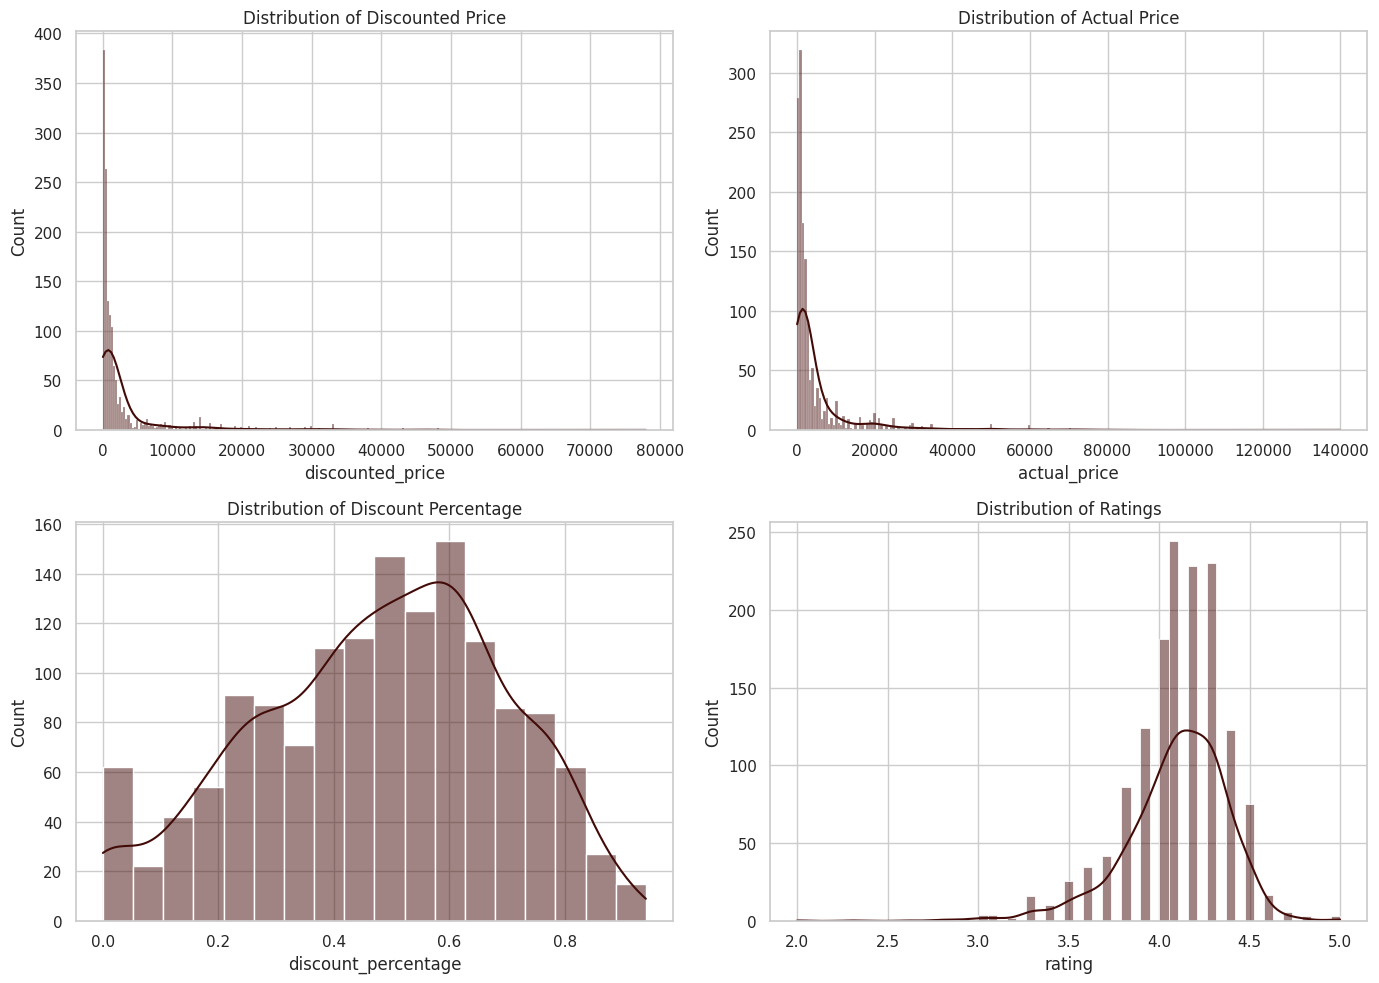

In [5]:
'''DISTRIBUTION PLOTS'''

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['discounted_price'], kde=True, ax=axes[0,0], color="#420b08")
axes[0,0].set_title("Distribution of Discounted Price")

sns.histplot(df['actual_price'], kde=True, ax=axes[0,1], color="#420b08")
axes[0,1].set_title("Distribution of Actual Price")

sns.histplot(df['discount_percentage'], kde=True, ax=axes[1,0], color="#420b08")
axes[1,0].set_title("Distribution of Discount Percentage")

sns.histplot(df['rating'], kde=True, ax=axes[1,1], color="#420b08")
axes[1,1].set_title("Distribution of Ratings")

plt.tight_layout()
plt.show()

/tmp/ipython-input-2628915741.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['rating'], order=df['rating'].value_counts().index, palette="muted")


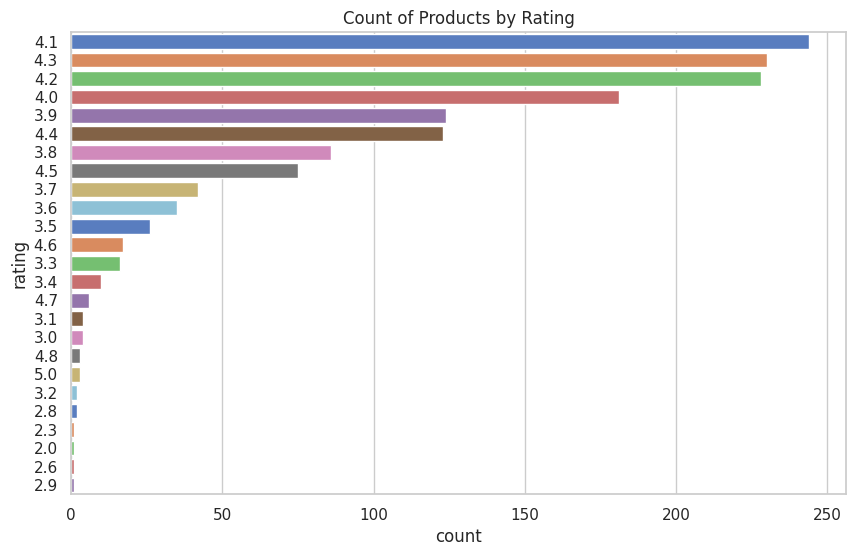

In [8]:
'''COUNT OF RATING'''

plt.figure(figsize=(10,6))
sns.countplot(y=df['rating'], order=df['rating'].value_counts().index, palette="muted")
plt.title("Count of Products by Rating")
plt.show()

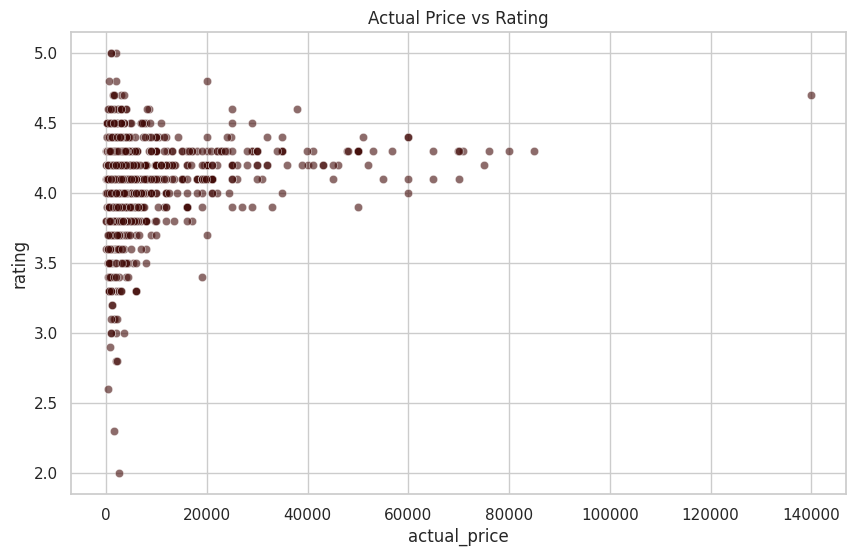

In [9]:
'''PRICE VS RATING'''
plt.figure(figsize=(10,6))
sns.scatterplot(x="actual_price", y="rating", data=df, alpha=0.6, color='#420b08')
plt.title("Actual Price vs Rating")
plt.show()

/tmp/ipython-input-1716214973.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('price_range')['rating_count']


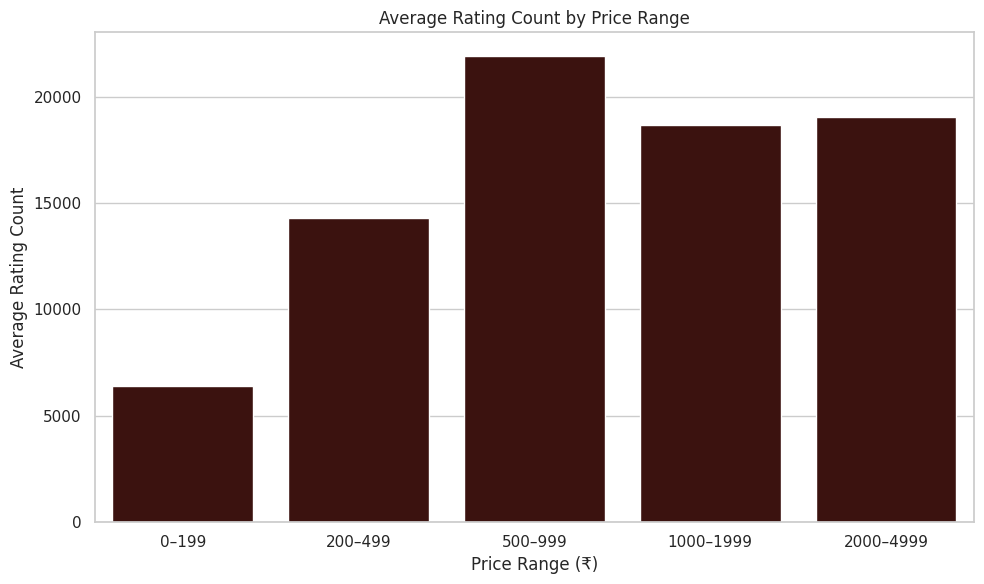

In [15]:
'''PRICE VS AVERAGE RATING'''
bins = [0, 200, 500, 1000, 2000, 5000]
labels = ["0–199", "200–499", "500–999", "1000–1999", "2000–4999"]

df['price_range'] = pd.cut(df['actual_price'], bins=bins, labels=labels)

price_vs_popularity = (
    df.groupby('price_range')['rating_count']
             .mean()
             .reset_index())

plt.figure(figsize=(10,6))
sns.barplot(data=price_vs_popularity, x='price_range', y='rating_count', color="#420b08")

plt.title("Average Rating Count by Price Range")
plt.xlabel("Price Range (₹)")
plt.ylabel("Average Rating Count")
plt.tight_layout()
plt.show()

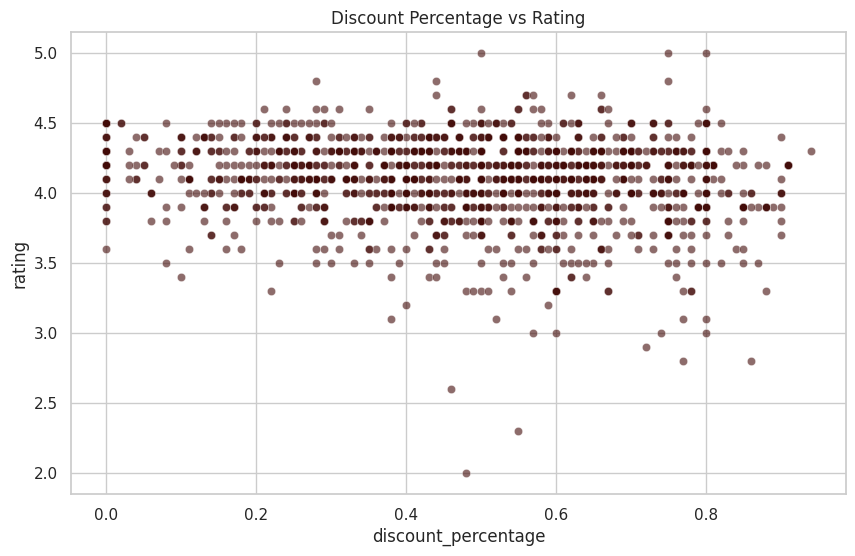

In [16]:
'''DISCOUNTS VS RATING'''
plt.figure(figsize=(10,6))
sns.scatterplot(df, x='discount_percentage', y='rating', alpha=0.6, color='#420b08')
plt.title("Discount Percentage vs Rating")
plt.show()

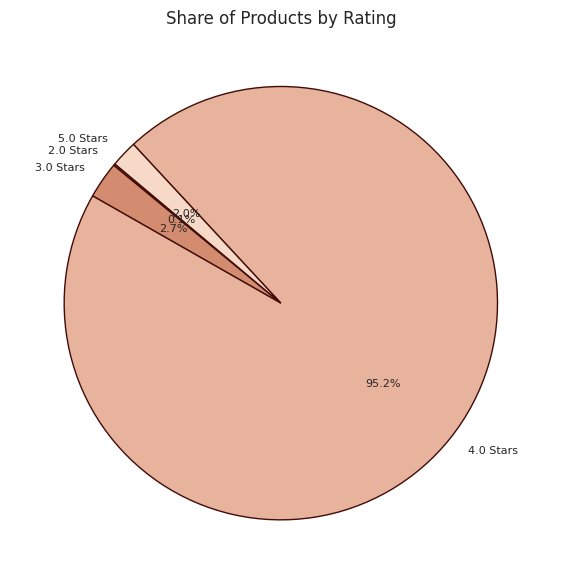

In [17]:
'''PERCENTAGE OF PRODUCTS VS RATING'''
df['rating_rounded'] = df['rating'].round()
rating_share = df['rating_rounded'].value_counts().sort_index()

plt.figure(figsize=(10,6))

colors = ["#a15c38", "#d48c70", "#e8b39c", "#f7d9c7", "#c47a57"]

plt.pie(
    rating_share,
    labels=rating_share.index.astype(str) + " Stars",
    autopct="%1.1f%%",
    startangle=140,
    colors=colors[:len(rating_share)],
    textprops={'fontsize': 8},
    wedgeprops={'edgecolor': '#420b08', 'linewidth': 1} )

plt.title("Share of Products by Rating", fontsize=12)
plt.tight_layout()
plt.show()

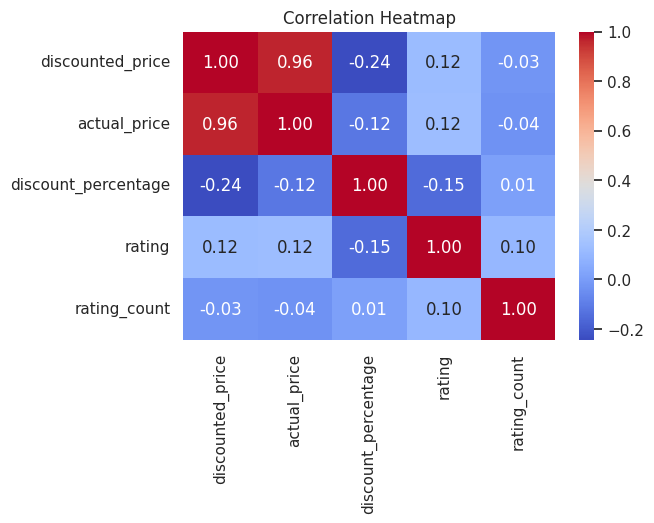

In [10]:
'''CORRELATION HEATMAP'''
plt.figure(figsize=(6,4))
sns.heatmap(df[['discounted_price','actual_price','discount_percentage','rating','rating_count']].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Observations
*   Prices are right-skewed (few high-priced products)
*   Discounts typically fall between 40%–70%
*   Most ratings are between 3.5 and 4.5 stars
*   95% of products are near 4 stars
*   Prices between 500 - 1000 have higher rating counts on average
*   There's no significant correlation between discount percentage and star rating


